# Frage 1
Laden Sie das Datenset "Daten_Frage_A.dat" (separat zur Verfügung gestellt) mit Zeit $t$ (in Einheiten von Sekunden) in Spalte 1 und Spannung $U$ (in Einheiten von Volt) in Spalte 2. Beantworten Sie die folgenden Fragen:

In [1]:
import numpy as np
t_1, u_1 = np.transpose(np.loadtxt('./Daten_Frage_A.txt', delimiter="|"))

Wie viele Punkte wurden gemessen?

In [2]:
print(len(t_1))

2001


Was ist die gesamte Messdauer?

In [3]:
print(t_1[-1] - t_1[0])

200.0


Was ist der zeitliche Abstand der Messpunkte?

In [4]:
unique_data = np.unique(t_1)
sorted_data = np.sort(unique_data)
differences = np.diff(sorted_data)
sorted_differences = np.sort(np.abs(differences))
resolution = np.min(sorted_differences)

print(resolution)

0.09999999999999432


Was ist der maximale gemessene Spannungswert?

In [5]:
print(np.max(u_1))

0.21990735817072385


Was ist der Mittelwert von $U$?

In [6]:
print(np.mean(u_1))

0.1198835386926476


Was ist die Standardabweichung von $U$?

In [7]:
print(np.std(u_1))

0.025333204570220483


# Frage 2
Sie haben in Ihrem Labor 4 Uhren, die Sie testen sollen, um sie als Messgerät für eine relative Zeitdauer in einem längeren Experiment zu verwenden. Eine Woche lang haben Sie die Uhren beobachtet und die Zeit, die sie anzeigen, mit einer Atomuhr der METAS in Bern verglichen. An jedem Wochentag haben Sie die Uhren um exakt 12:00 Uhr offizieller Schweizer Zeit abgelesen. Sie finden folgende Zeiten:

| **Uhr** | **Montag** | **Dienstag** | **Mittwoch** | **Donnerstag** | **Freitag** | **Samstag** | **Sonntag** |
|---------|------------|--------------|--------------|----------------|-------------|-------------|-------------|
| 1       | 12:36:40   | 12:36:56     | 12:37:12     | 12:37:27       | 12:37:44    | 12:37:59    | 12:38:14    |
| 2       | 11:59:59   | 12:00:02     | 11:59:57     | 12:00:07       | 12:00:02    | 11:59:56    | 12:00:03    |
| 3       | 15:50:45   | 15:51:43     | 15:52:41     | 15:53:39       | 15:54:37    | 15:55:35    | 15:56:33    |
| 4       | 12:03:59   | 12:02:49     | 12:01:54     | 12:01:52       | 12:02:32    | 12:01:22    | 12:00:12    |

Tipp: Betrachten Sie die Differenzen der Uhrenzeiten zur Atomuhrzeit für jedes nominelle 24h-Intervall. Nutzen Sie copy und paste für die Uhrzeitangaben, um Übertragungsfehler zu vermeiden. <br>
Sie können folgendes Code-Snippet zur Konvertierung der Uhrzeiten in reine Sekundenangaben verwenden:

In [13]:
def convert_time(t):
    """Diese Funktion konvertiert einen String,
    der eine Uhrzeit im 24h-Format (bspw. 12:02 bzw. 15:58:15) darstellt,
    in die Zahl der Sekunden, die seit 00:00:00 vergangen sind."""

    t = t.split(":")
    if len(t) == 2:
        return int(t[0])*3600 + int(t[1])*60
    else:
        return int(t[0])*3600 + int(t[1])*60 + int(t[2])

In [14]:
times = np.array([["12:36:40", "12:36:56", "12:37:12", "12:37:27", "12:37:44", "12:37:59", "12:38:14"],
                  ["11:59:59", "12:00:02", "11:59:57", "12:00:07", "12:00:02", "11:59:56", "12:00:03"],
                  ["15:50:45", "15:51:43", "15:52:41", "15:53:39", "15:54:37", "15:55:35", "15:56:33"],
                  ["12:03:59", "12:02:49", "12:01:54", "12:01:52", "12:02:32", "12:01:22", "12:00:12"]])

Welche Uhr hat die geringste durchschnittliche (systematischen) Abweichung zur Atomzeit?

In [18]:
conv_time = np.zeros(np.shape(times))
for i in range(0,np.shape(times)[0]):
    for j in range(0,np.shape(times)[1]):
        conv_time[i,j] = convert_time(times[i,j])

time_diff = conv_time - convert_time("12:00:00")
mean_diff = np.mean(time_diff, axis=1)

print(mean_diff)

[2.24742857e+03 8.57142857e-01 1.40190000e+04 1.25714286e+02]


Welche Uhr hat den geringsten statistischen Fehler?

In [20]:
std_diff = np.std(np.diff(conv_time), axis=1)
print(std_diff)

[ 0.74535599  6.3420992   0.         42.31003296]


Welches Kriterium ist entscheidend für die Zeitmessung im Experiment? <br>
--> *Die Uhr mit dem geringsten statistischen Fehler*

Welche der zur Auswahl stehenden Uhren eignet sich also am besten zur Zeitmessung im Experiment? <br>
--> *Uhr 3*

# Frage 3
Laden Sie das Datenset "Daten_Frage_B2.txt" (separat zur Verfügung gestellt) mit Zeit $t$ (in Einheiten von Sekunden) in Spalte 1 und dem Messwert $x$ (ohne Einheit) in Spalte 2. Berechnen Sie das erste Moment $M_1$, sowie das zweite und dritte zentrale Moment $\tilde{M}_2$, $\tilde{M}_3$. Geben Sie die Werte mit der angegeben Anzahl signifikanter Stellen an:

In [22]:
t_2, x_2 = np.transpose(np.loadtxt('./Daten_Frage_B2.txt', comments="#", delimiter=","))

def moment(data, n):
    return np.sum(data**n)/len(data)

In [23]:
m1 = moment(x_2, 1)
m2_zentral = moment(x_2-m1, 2)
m3_zentral = moment(x_2-m1, 3)

print(m1)
print(m2_zentral)
print(m3_zentral)

25.05571696645
9.111187760055891
4.632710281162971


Entscheiden Sie, ob die Daten normalverteilt sind oder nicht: <br>
--> *Nein, die Daten sind nicht normal verteilt, da* $\tilde{M}_3 \not\approx 0$.

# Frage 4
Sie haben die folgenden Parameter mit ihren Unsicherheiten bestimmt. Runden Sie sowohl die Unsicherheiten als auch die Werte auf eine angemessene Zahl von signifikanten Stellen.
1. Masse <br>
$m = 1.284975$ kg $\pm 0.037852$ kg --> $m = 1.28$ kg $\pm 0.04$ kg
2. Wellenlänge <br>
$\lambda=633.287657$ nm $\pm 0.937563$ nm --> $\lambda = 633.3$ nm $\pm 0.9$ nm
3. Frequenz <br>
$f = 587.8763748$ Hz $\pm 0.08137756$ Hz --> $f = 587.88$ Hz $\pm 0.08$ Hz
4. Temperatur <br>
$T = 23.1897645$ C $\pm 1.72179654$ C --> $T = 23$ C $\pm 2$ C

# Frage 5
Sie messen die Vibrationen $z(t)$ einer Tischplatte. Die Vibrationen werden mit einem Laserinterferometer und einer lichtempfindlichen Diode in ein Spannungssignal umgewandelt, wobei die Umwandlung insgesamt eine Umwandlungseffizienz (einen sogenannten Gain) von $g=10^6$ V/m hat. Im letzten Schritt wird diese Analogspannung mit einem Analog-Digital-Wandler (ADC) zu einem Datensatz $U$ verarbeitet. Der ADC fügt dem Signal Rauschen hinzu, das nicht mit $z(t)$ korreliert ist und dessen Varianz in einem Kontrollexperiment als $σ^2_{ADC}=3 \times 10^{−6}$ V$^2$ bestimmt wurde. <br>
Laden Sie das Datenset "Daten_Frage_C1.txt" (separat zur Verfügung gestellt) mit Zeit $t$ (in Einheiten von Sekunden) in Spalte 1 und Spannung $U$ (in Einheiten von Volt) in Spalte 2.

In [24]:
t_3, u_3 = np.transpose(np.loadtxt("./Daten_Frage_C1.txt", delimiter="	"))

Wie gross ist die gemessene Standardabweichung?

In [27]:
std_u = np.std(u_3)
print(std_u)

0.003321348866250454


Wie gross ist die tatsächliche Standardabweichung der Vibrationen, $\sigma_z$? <br>
-->
$$
    \sigma^2_U = g^2 \cdot \sigma^2_z + \sigma^2_{ADC} \implies \sigma_z = \frac{\sqrt{\sigma^2_U - \sigma^2_{ADC}}}{g}
$$

In [29]:
sigma_z =  np.sqrt(std_u**2 - 3e-6) / (1e6)
print(sigma_z)

2.833965118229788e-09


Bei welcher Frequenz hat das gemessene Signal einen Peak im Spektrum?

0.09993337774816789


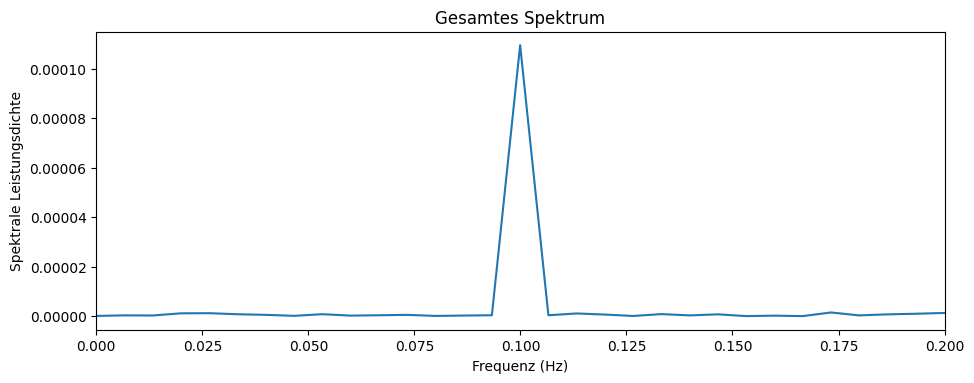

In [32]:
import matplotlib.pyplot as plt

N = len(t_3)
dt = t_3[1] - t_3[0]

# Berechnen der geordneten Frequenzachse
f = np.fft.fftfreq(N, dt)
f = np.fft.fftshift(f)  # Shift frequencies: negative to positive

# Berechnen der Fouriertransformation
spectrum = np.fft.fft(u_3) / N
spectrum = np.fft.fftshift(spectrum)  # Shift the spectrum accordingly

# Berechnen der spektralen Leistungsdichte
psd = dt * N * np.abs(spectrum)**2

cm = 1 / 2.54
fig = plt.figure(figsize=(25*cm, 10*cm))
ax = fig.add_subplot(1, 1, 1)
ax.plot(f, psd)
ax.set_xlim(0,0.2)
ax.set_xlabel('Frequenz (Hz)')
ax.set_ylabel(r'Spektrale Leistungsdichte')
ax.set_title('Gesamtes Spektrum')

fig.tight_layout()

print(-f[np.argmax(psd)])

Nun verwenden Sie einen Algorithmus, um die Daten zu mitteln. Die Zeit, über die gemittelt wird, beträgt 3 s. Über wie viele Punkte wird gemittelt und um welchen Faktor $\alpha$ wird sich die gemessene Standardabweichung $\sigma_{z,mittel} = \sigma_z / \alpha$ dadurch verringern?

In [33]:
n = 3 / dt
print(n)

30.0


In [34]:
print(np.sqrt(n))

5.477225575051661


# Frage 6
Sie messen die (einheitenlosen) Parameter $a$, $b$ und $c$ mit den folgenden Mittelwerten und Standardabweichungen: <br>
$\mu_a = 1.3$ <br>
$\sigma_a = 0.4$ <br>
$\mu_b = 8.1$ <br>
$\sigma_b = 0.64$ <br>
$\mu_c = 0.25$ <br>
$\sigma_c = 0.02$ <br>
Sie interessieren sich für den Wert der Funktion $f=a^2+3bc^3$. Berechnen Sie den Wert von $μ_f$ und $\sigma_f$ aus den Messwerten unter der Annahme, dass die Parameter $a$, $b$ und $c$ unkorreliert sind.

In [35]:
mu_a = 1.3
sigma_a = 0.4
mu_b = 8.1
sigma_b = 0.64
mu_c = 0.25
sigma_c = 0.02

In [36]:
mu_f = mu_a**2 + 3*mu_b*mu_c**3
print(mu_f)

2.0696875


$$
\begin{aligned}
    \partial_a f &= 2a \\
    \partial_b f &= 3c^3 \\
    \partial_c f &= 9bc^2
\end{aligned}
$$

In [37]:
d_a = 2*mu_a
d_b = 3*mu_c**3
d_c = 9*mu_b*mu_c**2

sigma_f = np.sqrt( d_a**2 * sigma_a**2 + d_b**2 * sigma_b**2 + d_c**2 * sigma_c**2 )
print(sigma_f)

1.0444155138760627


Erst später wird Ihnen bewusst, dass $b$ und $c$ korreliert sind (beide sind weiterhin unkorrerliert mit $a$). Die Kovarianz beträgt $\operatorname{cov}(b,c) = \sigma^2_{bc}=0.67$. Was sind nun die korrekt berechneten Werte?

In [38]:
print(mu_f)

2.0696875


In [41]:
sigma_bc = 0.67
sigma_f_cor = np.sqrt( sigma_f**2 + 2*d_b*d_c*sigma_bc )
print(sigma_f_cor)

1.173453543498847


# Frage 7
Laden Sie das Datenset "Daten_Frage_D2.txt" (separat zur Verfügung gestellt) mit Zeit $t$ (in Einheiten von Minuten) in Spalte 1, Periode $T$ (in Einheiten von Sekunden) in Spalte 2 und Masse $m$ (in Einheiten von Kilogramm) in Spalte 3. Die Messwerte entsprechen der Schwingungsperiode und Masse eines Pendels, die mehrere Male gemessen wurden. Aus diesen Grössen wollen wir die Federkonstante $k=m(\frac{2 \pi}{T})^2$ berechnen unter der Annahme, dass keine systematischen Fehler vorliegen (aber unter Berücksichtigung möglicher Kovarianzen).

In [63]:
t_4, T_4, m_4 = np.transpose(np.loadtxt("./Daten_Frage_D2.txt", delimiter="	"))

Was ist der Mittelwert und die Varianz der Periode?

In [64]:
mu_T = np.mean(T_4)
var_T = np.var(T_4)
print(mu_T, var_T)

1.6001863590039571 0.007230846480334927


Was ist der Mittelwert und die Varianz der Masse?

In [65]:
mu_m = np.mean(m_4)
var_m = np.var(m_4)
print(mu_m, var_m)

0.8057916862954384 0.014727704505713372


Was ist der berechtene Mittelwert und die Varianz der Federkonstante?

$$
\begin{aligned}
    \partial_m k &= \left( \frac{2 \pi}{T} \right)^2 \\
    \partial_T k &= -8 \pi^2 m T^{-3}
\end{aligned}
$$

In [59]:
cov_Tm = np.cov(T_4, m_4)[0,1]
d_m = (2*np.pi / mu_T)**2
d_T = (-8*np.pi**2 * mu_m) / (mu_T**3)

mu_k = mu_m * (2*np.pi / mu_T)**2
var_k = d_m**2 * var_m + d_T**2 * var_T + 2*d_m*d_T*cov_Tm

print(mu_k, var_k)

12.42342639322277 2.655352510182502


# Frage 8
Sie möchten mit einem Mikrophon ein Musikstück aufnehmen. Die höchste Frequenz, die ein menschliches Ohr normalerweise hören kann, ist 20 kHz. Wie lang darf der Abstand zwischen den Messpunkten maximal sein, damit diese Frequenz im Spektrum korrekt wiedergegeben wird?

In [66]:
dt = 1/(2*2e4)
print(dt)

2.5e-05


Das Mikrophon generiert weisses Rauschen mit einer spektralen Leistungdsdichte (PSD) von $5 \cdot 10^{−16}$ V$^2$/Hz (einseitig definiert). Wie viel Standarabweichung im Rauschen ist unvermeidlich, wenn Sie den gesamten Bereich von 0 bis 20 kHz in unserer Aufname ohne Filter wiedergeben wollen?

In [67]:
print(np.sqrt(5e-16*2e4))

3.1622776601683796e-06


# Frage 9
Laden Sie die Datei "rosengartenbruecke_2022_simplified.csv". Dieser Datensatz umfasst die Verkehrszahlen an der Rosengartenstrasse im Jahr 2022. Hierfür sind 2D-LiDAR Sensoren an der nördlichen Seite der Rosengartenbrücke in Richtung Bucheggplatz und in Richtung Hardbrücke montiert. Die einzelnen Fahrzeuge werden gemäss dem Klassierungssystem des ASTRA eingeteilt. Für jede Stunde eines Jahres wird erfasst, wie viele Fahrzeuge sich in welche Richtung bewegen und welchen Typ sie haben. Die Daten sind in einem CSV-File gespeichert. Die Spalten sind wie folgt definiert: Stunde, Fahrzeugklasse, Richtung, Anzahl.<br>

Um Ihnen das Einlesen auch mit den simplen Numpy-Funktionen zu erleichtern, falls Sie diese anstatt von Pandas-Dataframes verwenden wollen, haben wir für die Spalten Fahrzeugklasse und Richtung die Werte in numerische Werte umgewandelt. Hierbei gilt folgende Zuordnung für die Fahrzeugklasse: {0: 'Bus', 1: 'Lastenzug', 2: 'Lastwagen', 3: 'Lieferwagen', 4: 'Lieferwagen mit Anhänger', 5: 'Lieferwagen mit Auflieger', 6: 'Motorrad', 7: 'Personenwagen', 8: 'Personenwagen mit Anhänger', 9: 'Sattelzug', 10: 'Trolleybus', 11: 'Unbekannt'}. Für die Richtung gilt die Zuordnung {0: 'Bucheggplatz', 1: 'Hardbrücke'}.<br>

Lesen Sie die Daten ein. Hierbei ist die Spalte Stunde ein Integer-Wert, der zwischen 0 und 8759 liegt (24 Stunden pro Tag * 365 Tage).

In [125]:
import pandas as pd
data9 = pd.read_csv("./rosengartenbruecke_2022_simplified.txt")

Fuhren im Januar mehr Busse Richtung Bucheggplatz oder Hardbrücke?

In [126]:
df_jan_bus = data9[(data9["hour"] >= 0) &
                   (data9["hour"] < 31*24) &
                   (data9["Fahrzeugklasse"] == 0)]

attributes = df_jan_bus.groupby("Richtung")["Anzahl"].sum()

print(attributes)

Richtung
0    881
1    475
Name: Anzahl, dtype: int64


Wie viele Fahrzeuge fahren im Jahr 2022 Richtung Bucheggplatz und wie viele Richtung Hardbrücke? Geben Sie die Anzahl der Fahrzeuge in Millionen an. Runden Sie auf 2 Dezimalstellen.

In [86]:
attributes = data9.groupby("Richtung")["Anzahl"].sum()
print(attributes)

Richtung
0    11461876
1    10056663
Name: Anzahl, dtype: int64


Wie hoch ist der Rekord an Motorrädern, die in einer Stunde in die Richtung Bucheggplatz fahrend gemessen wurden?

In [90]:
df_mot = data9[(data9["Fahrzeugklasse"] == 6) &
               (data9["Richtung"] == 0)]

attributes = df_mot["Anzahl"].max()

print(attributes)

514


Tragen Sie die mittlere Anzahl aller Fahrzeuge pro Tagesstunde für die Richtung Hardbrücke gegen die Tageszeit auf. Summieren Sie hierfür zunächst über die verschiedenen Fahrzeugkategorien und mitteln Sie dann die Fahrzeuge pro Tagesstunde, indem Sie den Modulo-Operator (% bzw. np.mod(...)) verwenden. Zu welchen beiden Tageszeiten können Sie eine "rush hour" (lokales Maximum der Verkehrsauslastung) beobachten? (Angabe im 24h-Format, startend bei 0 Uhr, Werte in aufsteigender Reihenfolge angeben)

In [98]:
df_hour = data9[data9["Richtung"] == 1].copy()
df_hour.loc["hour"] = np.mod(df_hour["hour"], 24)

attributes = df_hour.groupby(["hour"])["Anzahl"].mean()
print(attributes)

hour
0.0      22.404338
1.0      16.297717
2.0      15.465982
3.0      21.436758
4.0      45.598630
5.0      93.736073
6.0     127.806164
7.0     136.661644
8.0     128.486986
9.0     121.611872
10.0    123.737671
11.0    125.706621
12.0    129.657078
13.0    133.858447
14.0    137.297032
15.0    147.100000
16.0    154.980137
17.0    148.825799
18.0    123.542237
19.0     98.247717
20.0     81.191096
21.0     70.363927
22.0     56.341096
23.0     35.686758
Name: Anzahl, dtype: float64


# Frage 10
Sie messen eine binomialverteilte Zufallsvariable $N=100$ mal. Die Zufallsvariable kann die Werte $x=1$ bzw. $x=0$ annehmen. Sie messen als Ergebnis die Summe aller möglichen Ergebnisse: $X=\sum_{n=1}^N x_n$.<br>
Was ist der Erwartungswert dieser Messung, wenn  die Zufallsvariable mit einer die Wahrscheinlichkeit von $p=0.3$ den Wert $x=1$ annimmt?

In [101]:
n = 100
p = 0.3

E_X = n*p

print(E_X)

30.0


Was ist die Standardabweichung?



In [103]:
sigma_X = np.sqrt(n*p*(1-p))

print(sigma_X)

4.58257569495584


# Frage 11
Nehmen Sie an, es gibt eine Infektionskrankheit mit einer Inzidenzrate von 100. Das bedeutet, dass 100 von 100000 Menschen, also 0.1 %, infiziert sind. Eine Person lässt sich nun testen und der Test ist positiv. <br>
Wie hoch ist die Wahrscheinlichkeit, dass die Person tatsächlich infiziert ist, wenn der Test in 99% der Fälle das korrekte Ergebnis liefert?

In [104]:
inzidenz = 0.001
test_korrekt = 0.99
test_positiv = test_korrekt * inzidenz + (1-test_korrekt) * (1-inzidenz)

positiv_infiziert = test_korrekt * inzidenz / test_positiv

print(positiv_infiziert)

0.09016393442622944


Der Proband lässt sich nun ein weiteres Mal testen und der Test ist erneut positiv.

In [105]:
inzidenz_neu = positiv_infiziert
test_positiv_neu = test_korrekt * inzidenz_neu + (1-test_korrekt) * (1-inzidenz_neu)

positiv_infiziert_neu = test_korrekt * inzidenz_neu / test_positiv_neu

print(positiv_infiziert_neu)

0.9074999999999999


# Frage 12
Sie beobachten die Emission von Einzel-Photonen in einem Experiment. Sie beobachten folgende Anzahl an Emissionen:<br>

Experiment 1: 5 Emissionen<br>
Experiment 2: 8 Emissionen<br>

Sie haben drei verschiedene Vorhersagen, die Sie gegeneinander testen möchten. Vorhersage $H_1$ besagt, dass die Emission Poisson-verteilt ist mit einem Erwartungswert von 2. $H_2$ und $H_3$ entsprechend mit Erwartungswerten 9 bzw. 20. <br>

Frage: Welche Hypothese hat mit diesen beiden Experimenten die grösste Gültigkeit? Berechnen Sie die Likelihood aller Hypothesen und vergleichen Sie.

In [109]:
def likelihood(mu):
    return mu**(5 + 8) * np.exp(-2*mu)

H1 = likelihood(2)
H2 = likelihood(9)
H3 = likelihood(20)

print(H1, H2, H3)

150.0417137765104 38712.56507922786 0.34802518059348697


# Frage 13
Laden Sie das Datenset "Daten_Frage_H1.txt" (separat zur Verfügung gestellt). Dieser Datensatz beinhaltet $x$ in Spalte 1, $y$ in Spalte 2 sowie die die Standardabweichung jedes Wertes von $y$ (also $\sigma$) in Spalte 3. Fitten Sie ein Polynom 3-ten Grades an den Datensatz ($f(x)=a_0+a_1x+a_2x^2+a_3x^3£). Geben Sie die Werte der Fitparameter jeweils mit der angegebenen Anzahl von Nachkommastellen an. Berechnen Sie die Residuen und entscheiden Sie, ob die Daten gut durch ein Polynom 3-ten Grades beschrieben werden können.

In [9]:
x_13, y_13, sigma_13 = np.transpose(np.loadtxt("./Daten_Frage_H1.txt", comments="#", delimiter=","))

In [8]:
def linear_fit(x,y,sigma,m):

    # Gewichte
    w = 1/(sigma**2)

    # N und Y
    N = np.zeros((m+1,m+1))
    Y = np.zeros(m+1)

    for i in range(0,m+1):
        Y[i] = np.sum(w * y * x**i)
        for j in range(i,m+1):
            val = np.sum(w * x**(i+j))
            N[i,j] = val
            if i != j:
                N[j,i] = val

    A = np.linalg.solve(N, Y)
    C = np.linalg.inv(N)

    return A,C

In [10]:
A, C = linear_fit(x_13, y_13, sigma_13, 3)
print(A)

[ 14.54435323 -11.76103183   3.98920742  -0.33984843]


Entscheiden Sie, ob die Daten gut durch ein Polynom 3-ten Grades beschrieben werden können:

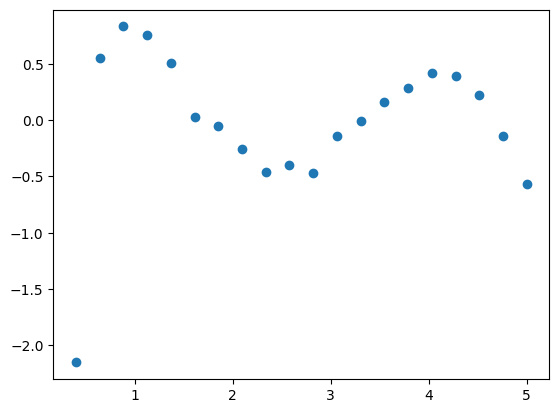

In [11]:
y_fit =np.polyval(A[::-1], x_13)
residues = y_fit - y_13

import matplotlib.pyplot as plt
plt.scatter(x_13, residues)

# Frage 14
Betrachten Sie den Datensatz unten. Er enthält 10 Einträge, wobei jeder Eintrag aus einem Feature $(x)$ und einem Label $(y)$ besteht:

| **x** | **y** |
|-------|-------|
| 1     | 0     |
| 2     | 1     |
| 3     | 0     |
| 4     | 0     |
| 5     | 0     |
| 6     | 1     |
| 7     | 1     |
| 8     | 1     |
| 9     | 1     |
| 10    | 1     |

Nehmen Sie an, dass wir ein Modell haben, das aus allen Klassifizierungsbäumen der Form "Falls $x \leq d$ dann $y=0$ anderenfalls $y=1$" besteht. Welcher Wert von $d$ ergibt einen Baum, der die 0-1 Verlustfunktion im obigen Datensatz minimiert? <br>
--> wir gehen systematisch durch alle Punkte und minimieren die Anzahl falscher Klassifizierung. Das ist bei 5.

# Frage 15
Nehmen Sie an, dass Sie einen Algorithmus haben, der einen Schätzer mittels der 0-1 Verlustfunktion für das Modell "Falls $x \leq d$ dann $y=0$ anderenfalls $y=1$" und den folgenden Datensatz berechnet:

| **x** | **y** |
|-------|-------|
| 1     | 0     |
| 2     | 1     |
| 3     | 0     |
| 4     | 0     |
| 5     | 0     |
| 6     | 1     |
| 7     | 1     |
| 8     | 1     |
| 9     | 1     |
| 10    | 1     |

Sie führen diesen Algorithmus mit Leave-one-out Kreuzvalidierung aus. Für welchen Anteil der Teilmengen (Folds) erreicht der berechnete Schätzer eine Genauigkeit von 100%? <br>

--> Dabei wird der Reihe nach ein Element aus der Reihe entfernt, $d$ für die übrige Liste bestimmt und dann überprüft, ob das entfernte Element richtig klassifiziert wird. Alle punkte ausser $x_2$ werden richtig klassifiziert. Damit hat der Schätzer eine Genauigkeit von 90%

# Frage 16
--> auf Papier lösen. Faltung ist standardmässig stride = 1, pooling ist standardmässig stride = n, wobei n die Grösse der Poolmatrix ist.

# Frage 17
In dieser Aufgabe implementieren Sie ein Programm, das lernt, Iris-Arten anhand ihrer Sepalen- und Petalen-Messungen zu klassifizieren.<br>
Öffnen Sie zuallererst das Python-File `main.py`, in dem einige Schritte bereits für Sie gelöst sind. Hier verwenden Sie pandas, um den Datensatz `data.csv` in einen DataFrame `df` zu laden. Wenn Sie `df.head()` ausführen, erhalten Sie:
| sepal length (cm) | sepal width (cm) | ... | petal width (cm) | target |   |
|-------------------|------------------|-----|------------------|--------|---|
| 0                 | 4.6              | ... | 3.6              | 0.2    | 0 |
| 1                 | 5.7              | ... | 4.4              | 0.4    | 0 |
| 2                 | 6.7              | ... | 3.1              | 1.4    | 1 |
| 3                 | 4.8              | ... | 3.4              | 0.2    | 0 |
| 4                 | 4.4              | ... | 3.2              | 0.2    | 0 |

Jede Zeile stellt eine Iris-Blume dar. Die letzte Spalte `target` ist eine Ganzzahl (0, 1 oder 2), welche die Iris-Art repräsentiert. Alle anderen Spalten beschreiben die Sepalen- und Petalen-Messungen der Blume. <br>
Anschliessend erstellen Sie zwei DataFrames `X` und `y`. Hierbei soll `y` nur die Arten enthalten und `X` alle anderen Spalten. Soweit ist alles bereits im Code vorhanden.<br>
Teilen Sie nun `(X, y)` mit Hilfe der Funktion `train_test_split` von Scikit in einen Trainingsdatensatz `(X_train, y_train)` und einen Testdatensatz `(X_test, y_test)` auf, erstellen Sie ein Modell und trainieren Sie es anschliessend mit dem Trainingsdatensatz. <br>
1. Verwenden Sie den resultierenden Schätzer, um die Iris-Blumen in `X_test` zu klassifizieren, und erstellen Sie einen DataFrame `y_pred`, der die Vorhersagen des Schätzers für jede Blume in `X_test` enthält.
2. Bewerten Sie die Genauigkeit der vom Schätzer vorgenommenen Vorhersagen anhand von `y_test` als Grundlage. Verwenden Sie dafür die Funktion `accuracy_score` von Scikit. Dies dient Ihnen als Absicherung, dass Ihr Algorithmus funktioniert.

Verwenden Sie dann wiederum pandas, um den Datensatz `X_final.csv` in einen DataFrame `df` zu laden. Wenn Sie `df.head()` ausführen, erhalten Sie:

| # | sepal length (cm) | sepal width (cm) | petal length (cm) | petal width (cm) | target |
|---|-------------------|------------------|-------------------|------------------|--------|
| 0 | 6.8               | 3.2              | 5.9               | 2.3              | 0      |
| 1 | 6.3               | 3.3              | 4.7               | 1.6              | 0      |
| 2 | 6.4               | 2.8              | 5.6               | 2.1              | 1      |
| 3 | 5.6               | 2.5              | 3.9               | 1.1              | 0      |
| 4 | 6.2               | 2.2              | 4.5               | 1.5              | 0      |

Beachten Sie, dass dies ein Datensatz ist, der Iris-Blumen beschreibt, ohne jedoch deren Art anzugeben. Diese Art-Etiketten sind vor Ihnen verborgen. Verwenden Sie Ihren Schätzer, um diese Blumen zu klassifizieren:

In [53]:
# Task 1: Read the data from data.csv

# Hint: This one we already solved for you ;)
import pandas as pd
import numpy as np

df = pd.read_csv("data.txt")

X = df.drop(['target'], axis=1)
y = df['target']

# Task 2: Split data into training and testing.

from sklearn.model_selection import train_test_split

# Hint: this function takes as parameter X, y, and a 'test_size' ;)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Task 3: Train a model on your data.

# Hint 1: Below are some options for models ;)
# Hint 2: To train a model, use the method 'fit' with some X and some y.
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(hidden_layer_sizes=(30, 30, 30), max_iter=5000)
model.fit(X_train, y_train)

# Task 4: Measure the quality of your estimator in the test data.

from sklearn.metrics import accuracy_score

# Hint: Here you use your estimator to 'predict' the labels for your
# test data.
y_pred =  model.predict(X_test)

# Hint: Call accuracy_score with the following arguments:
# 1. the true labels.
# 2. the labels you predicted.
acc = accuracy_score(y_test, y_pred)

print("Accuracy of classif. tree on test data: {:.3f}".format(acc))

# Task 5: Use your estimator to make predictions for the examples in X_final.csv
X_final = pd.read_csv('X_final.txt')
y_final = model.predict(X_final)
print(y_final)

Accuracy of classif. tree on test data: 0.958
[2 1 2 1 2 1 0 2 0 1]
